In [1]:
import cv2
import matplotlib.pyplot as plt

In [2]:
config_file = 'ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt'
fozen_model = 'frozen_inference_graph.pb'

In [3]:
model = cv2.dnn.readNetFromTensorflow(fozen_model, config_file)

In [4]:
classLabels = []
file_name = 'labels.txt'
with open(file_name, 'rt') as fpt:
    classLabels = fpt.read().rstrip('\n').split('\n')
print(classLabels)

['person', 'bicycle', 'car', 'motorbike', 'aeroplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'sofa', 'pottedplant', 'bed', 'diningtable', 'toilet', 'tvmonitor', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush']


In [5]:
print(len(classLabels))

80


In [7]:
detection_model = cv2.dnn_DetectionModel(model)
detection_model.setInputSize(320, 320)
detection_model.setInputScale(1.0 / 127.5)
detection_model.setInputMean(127.5)
detection_model.setInputSwapRB(True)

< cv2.dnn.Model 0000022167367E50>

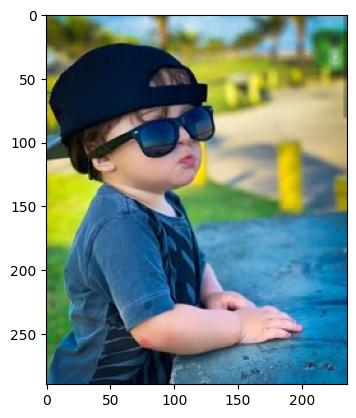

In [ ]:
img = cv2.imread('boy.jpg')
if img is not None:
	plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
	plt.axis('on') #off
	plt.show()
else:
	print("Image not found or unable to load.")

In [12]:
ClassIndex, confidence, bbox = detection_model.detect(img, confThreshold=0.5)

In [13]:
print(ClassIndex)

[1]


In [14]:
font_scale = 3
font = cv2.FONT_HERSHEY_PLAIN
for ClassIndex, confidence, box in zip(ClassIndex.flatten(), confidence.flatten(), bbox):
    cv2.rectangle(img, box, color=(0, 255, 0), thickness=3)
    cv2.putText(img, classLabels[ClassIndex - 1], (box[0] + 10, box[1] + 40), font, font_scale, (255, 255, 255), thickness=3)

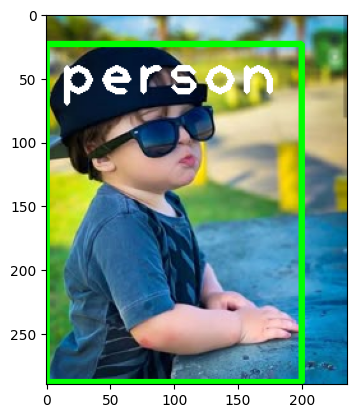

In [15]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

In [17]:
# Video

cap = cv2.VideoCapture('sample_object.mp4')
if not cap.isOpened():
    cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error opening video stream or file")
    exit(0)

font_scale = 1
font = cv2.FONT_HERSHEY_PLAIN
while cap.isOpened():
    ret, img = cap.read()
    if not ret:
        break

    ClassIndex, confidence, bbox = detection_model.detect(img, confThreshold=0.5)

    for ClassIndex, confidence, box in zip(ClassIndex.flatten(), confidence.flatten(), bbox):
        cv2.rectangle(img, box, color=(0, 255, 0), thickness=3)
        cv2.putText(img, classLabels[ClassIndex - 1], (box[0] + 10, box[1] + 40), font, font_scale, (255, 255, 255), thickness=3)

    cv2.imshow('Object Detection', img)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

KeyboardInterrupt: 

In [ ]:
# Webcam
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error opening video stream or file")
    exit(0)
font_scale = 1
font = cv2.FONT_HERSHEY_PLAIN
while cap.isOpened():
    ret, img = cap.read()
    if not ret:
        break

    ClassIndex, confidence, bbox = detection_model.detect(img, confThreshold=0.5)

    for ClassIndex, confidence, box in zip(ClassIndex.flatten(), confidence.flatten(), bbox):
        cv2.rectangle(img, box, color=(0, 255, 0), thickness=3)
        cv2.putText(img, classLabels[ClassIndex - 1], (box[0] + 10, box[1] + 40), font, font_scale, (255, 255, 255), thickness=3)

    cv2.imshow('Object Detection', img)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()
# Release the video capture object
cap.release()
# Close all OpenCV windows
cv2.destroyAllWindows()